Counts before balancing:
{'AtopicDermatitis_Eczema': 1724, 'Bacterial_Infections': 288, 'Benign_SkinTumors': 1853, 'ConnectiveTissue_Autoimmune': 606, 'DrugReactions_Exanthems': 404, 'Fungal_NailInfections': 2340, 'Miscellaneous_SkinDisorders': 840, 'Pigmentation_Vitiligo': 568, 'Psoriasis_LichenPlanus': 1405, 'SkinCancer_Precancer': 1612, 'Urticaria_Allergic': 472, 'Viral_SkinInfections': 1491}

Balancing dataset...


Balancing classes: 100%|██████████| 12/12 [09:50<00:00, 49.17s/it]



Counts after balancing:
{'AtopicDermatitis_Eczema': 2340, 'Bacterial_Infections': 2340, 'Benign_SkinTumors': 2340, 'ConnectiveTissue_Autoimmune': 2340, 'DrugReactions_Exanthems': 2340, 'Fungal_NailInfections': 2340, 'Miscellaneous_SkinDisorders': 2340, 'Pigmentation_Vitiligo': 2340, 'Psoriasis_LichenPlanus': 2340, 'SkinCancer_Precancer': 2340, 'Urticaria_Allergic': 2340, 'Viral_SkinInfections': 2340}


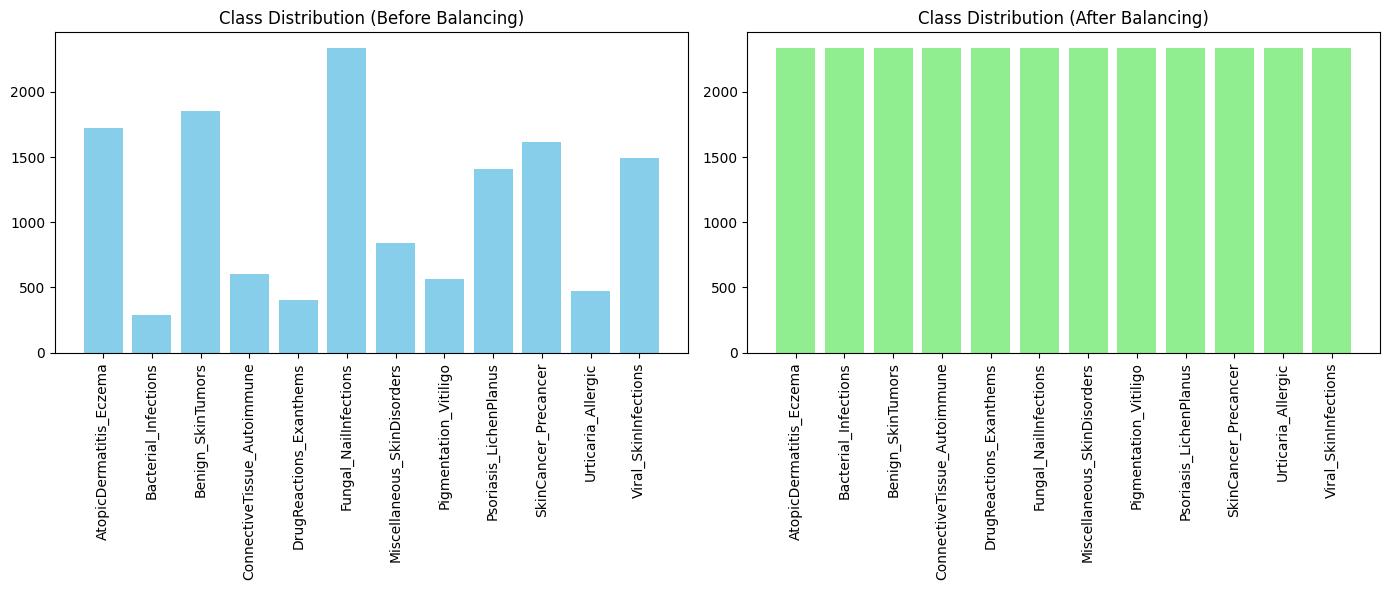

In [1]:
import os
import shutil
import random
import uuid
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img

# -----------------------------
# CONFIG
# -----------------------------
DATA_ROOT = r"C:\Users\BME\Desktop\skin_dataset_13labels"   # replace with your dataset path
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
BALANCED_DIR = os.path.join(DATA_ROOT, "train_balanced")  # new balanced output folder

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# -----------------------------
# FUNCTION TO COUNT FILES PER CLASS
# -----------------------------
def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

# -----------------------------
# BALANCE DATASET
# -----------------------------
def balance_dataset(input_dir, output_dir, target_count=None, mode="oversample"):
    """
    mode = "oversample" -> upsample minority classes
    mode = "undersample" -> downsample majority classes
    mode = "hybrid" -> mix of both
    """
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)  # clear if already exists
    os.makedirs(output_dir, exist_ok=True)

    counts = count_images(input_dir)
    max_count = max(counts.values())
    min_count = min(counts.values())

    if target_count is None:
        if mode == "oversample":
            target_count = max_count
        elif mode == "undersample":
            target_count = min_count
        elif mode == "hybrid":
            target_count = (max_count + min_count) // 2

    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode="nearest"
    )

    for cls, count in tqdm(counts.items(), desc="Balancing classes"):
        cls_in = os.path.join(input_dir, cls)
        cls_out = os.path.join(output_dir, cls)
        os.makedirs(cls_out, exist_ok=True)

        images = os.listdir(cls_in)

        # -----------------------------
        # COPY ORIGINAL IMAGES
        # -----------------------------
        for img_name in images:
            shutil.copy(os.path.join(cls_in, img_name), os.path.join(cls_out, img_name))

        # -----------------------------
        # OVERSAMPLING
        # -----------------------------
        if mode in ["oversample", "hybrid"] and count < target_count:
            augment_needed = target_count - count
            i = 0
            while i < augment_needed:
                img_name = random.choice(images)
                img_path = os.path.join(cls_in, img_name)

                img = load_img(img_path, target_size=IMG_SIZE)
                x = img_to_array(img)
                x = x.reshape((1,) + x.shape)

                for batch in datagen.flow(x, batch_size=1):
                    new_name = f"aug_{i}{uuid.uuid4().hex[:6]}{img_name}"
                    save_path = os.path.join(cls_out, new_name)
                    array_to_img(batch[0]).save(save_path)
                    i += 1
                    if i >= augment_needed:
                        break

        # -----------------------------
        # UNDERSAMPLING
        # -----------------------------
        elif mode in ["undersample", "hybrid"] and count > target_count:
            keep_images = random.sample(images, target_count)
            # First clear folder
            shutil.rmtree(cls_out)
            os.makedirs(cls_out, exist_ok=True)
            for img_name in keep_images:
                shutil.copy(os.path.join(cls_in, img_name), os.path.join(cls_out, img_name))

    return count_images(output_dir)

# -----------------------------
# RUN
# -----------------------------
print("Counts before balancing:")
train_counts_before = count_images(TRAIN_DIR)
print(train_counts_before)

print("\nBalancing dataset...")
train_counts_after = balance_dataset(TRAIN_DIR, BALANCED_DIR, mode="oversample")

print("\nCounts after balancing:")
print(train_counts_after)

# -----------------------------
# PLOT BAR GRAPH
# -----------------------------
plt.figure(figsize=(14, 6))

# Before balancing
plt.subplot(1, 2, 1)
plt.bar(train_counts_before.keys(), train_counts_before.values(), color="skyblue")
plt.title("Class Distribution (Before Balancing)")
plt.xticks(rotation=90)

# After balancing
plt.subplot(1, 2, 2)
plt.bar(train_counts_after.keys(), train_counts_after.values(), color="lightgreen")
plt.title("Class Distribution (After Balancing)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [6]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201, EfficientNetB4
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import AUC
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -----------------------------
# CONFIG
# -----------------------------
DATA_ROOT = r"C:\Users\BME\Desktop\skin_dataset_13labels\train_balanced" # dataset path
IMG_SIZE = (380, 380)   # EfficientNetB4 recommended input size
BATCH_SIZE = 16
EPOCHS = 40
INITIAL_LR = 1e-4
NUM_CLASSES = 12  # change if different

# -----------------------------
# DATA PREP
# -----------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2  # we'll use stratified later if needed
)

train_generator = train_datagen.flow_from_directory(
    DATA_ROOT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='training',
    class_mode='categorical',
    color_mode="rgb"
)

val_generator = train_datagen.flow_from_directory(
    DATA_ROOT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='validation',
    class_mode='categorical',
    color_mode="rgb"
)

# -----------------------------
# HYBRID MODEL (DenseNet201 + EfficientNetB4)
# -----------------------------
input_tensor = Input(shape=IMG_SIZE + (3,))

# Base Models
base1 = DenseNet201(include_top=False, weights="imagenet", input_tensor=input_tensor)
base2 = EfficientNetB4(include_top=False, weights="imagenet", input_tensor=input_tensor)



# Freeze base layers initially
for layer in base1.layers:
    layer.trainable = False
for layer in base2.layers:
    layer.trainable = False

# Feature extraction
x1 = GlobalAveragePooling2D()(base1.output)
x2 = GlobalAveragePooling2D()(base2.output)

# Combine features
x = Concatenate()([x1, x2])
x = Dropout(0.5)(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=input_tensor, outputs=output)

# -----------------------------
# OPTIMIZER + LOSS
# -----------------------------
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=1000,
    alpha=1e-5
)

optimizer = Adam(learning_rate=lr_schedule)

loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

metrics = [
    "accuracy",
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
    AUC(name="auc")
]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# -----------------------------
# CALLBACKS
# -----------------------------
checkpoint = ModelCheckpoint(
    "hybrid_best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# -----------------------------
# PHASE 1: Train only head
# -----------------------------
print("🔵 Phase 1: Training head (frozen base models)...")
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

# -----------------------------
# PHASE 2: Fine-tuning last layers
# -----------------------------
print("🟢 Phase 2: Fine-tuning last layers...")

for layer in base1.layers[-100:]:   # unfreeze last 100 layers of DenseNet
    layer.trainable = True
for layer in base2.layers[-50:]:    # unfreeze last 50 layers of EfficientNet
    layer.trainable = True

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

# -----------------------------
# FINAL SAVE
# -----------------------------
model.save("hybrid_final_model.keras")
print("✅ Training complete. Model saved as hybrid_final_model.keras")

Found 22464 images belonging to 12 classes.
Found 5616 images belonging to 12 classes.


ValueError: Shape mismatch in layer #1 (named stem_conv)for weight stem_conv/kernel. Weight expects shape (3, 3, 1, 48). Received saved weight with shape (3, 3, 3, 48)

In [2]:
import os
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201, EfficientNetB4
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.metrics import AUC
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# -----------------------------
# CONFIG
# -----------------------------
DATA_ROOT = r"C:\Users\BME\Desktop\skin_dataset_13labels\train_balanced"
IMG_SIZE = (380, 380)
BATCH_SIZE = 16
EPOCHS = 40
INITIAL_LR = 1e-4

# Verify directory exists
if not os.path.exists(DATA_ROOT):
    raise FileNotFoundError(f"Directory {DATA_ROOT} does not exist.")

# -----------------------------
# DATA PREP
# -----------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_ROOT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='training',
    class_mode='categorical',
    color_mode="rgb"
)

val_generator = val_datagen.flow_from_directory(
    DATA_ROOT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='validation',
    class_mode='categorical',
    color_mode="rgb"
)

# Dynamically set number of classes
NUM_CLASSES = len(train_generator.class_indices)
print(f"Detected {NUM_CLASSES} classes: {train_generator.class_indices}")

# Compute class weights for imbalanced datasets
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

# -----------------------------
# MODEL BUILDING
# -----------------------------
# Define input
input_tensor = Input(shape=(380, 380, 3))

# Base models
base1 = DenseNet201(include_top=False, weights="imagenet", input_tensor=input_tensor)
x1 = GlobalAveragePooling2D()(base1.output)

base2 = EfficientNetB4(include_top=False, weights=None, input_tensor=input_tensor)
# Load EfficientNetB4 weights manually
weights_path = tf.keras.utils.get_file(
    'efficientnetb4_notop.h5',
    'https://storage.googleapis.com/keras-applications/efficientnetb4_notop.h5',
    cache_subdir='models'
)
base2.load_weights(weights_path, by_name=True, skip_mismatch=True)
x2 = GlobalAveragePooling2D()(base2.output)

# Freeze base models
base1.trainable = False
base2.trainable = False

# Combine
x = Concatenate()([x1, x2])
x = Dropout(0.5)(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

# Build model
model = Model(inputs=input_tensor, outputs=output)

# -----------------------------
# COMPILE
# -----------------------------
steps_per_epoch = train_generator.samples // BATCH_SIZE
decay_steps = steps_per_epoch * EPOCHS
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=decay_steps,
    alpha=1e-5
)
optimizer = Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

# -----------------------------
# CALLBACKS
# -----------------------------
checkpoint = ModelCheckpoint(
    "hybrid_best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)
csv_logger = CSVLogger('training_log.csv', append=True)

# -----------------------------
# TRAINING - PHASE 1 (Frozen Base)
# -----------------------------
print("🔵 Phase 1: Training head (frozen base models)...")
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint, early_stop, csv_logger],
    class_weight=class_weights,
    verbose=1
)

# -----------------------------
# TRAINING - PHASE 2 (Fine-tuning)
# -----------------------------
print("🟢 Phase 2: Fine-tuning base models...")
for layer in base1.layers[-100:]:
    layer.trainable = True
for layer in base2.layers[-50:]:
    layer.trainable = True

# Re-compile with lower learning rate for fine-tuning
lr_schedule_finetune = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=INITIAL_LR / 10,
    decay_steps=decay_steps,
    alpha=1e-5
)
optimizer = Adam(learning_rate=lr_schedule_finetune)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, csv_logger],
    class_weight=class_weights,
    verbose=1
)

# -----------------------------
# SAVE FINAL MODEL
# -----------------------------
try:
    model.save("hybrid_final_model.keras")
    print("✅ Training complete. Model saved.")
except Exception as e:
    print(f"❌ Error saving model: {e}")

Found 22464 images belonging to 12 classes.
Found 5616 images belonging to 12 classes.
Detected 12 classes: {'AtopicDermatitis_Eczema': 0, 'Bacterial_Infections': 1, 'Benign_SkinTumors': 2, 'ConnectiveTissue_Autoimmune': 3, 'DrugReactions_Exanthems': 4, 'Fungal_NailInfections': 5, 'Miscellaneous_SkinDisorders': 6, 'Pigmentation_Vitiligo': 7, 'Psoriasis_LichenPlanus': 8, 'SkinCancer_Precancer': 9, 'Urticaria_Allergic': 10, 'Viral_SkinInfections': 11}
🔵 Phase 1: Training head (frozen base models)...


c:\Users\BME\anaconda3\envs\skin_classification_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.4748 - auc: 0.8237 - loss: 1.8698 - precision_1: 0.8757 - recall_1: 0.2505 
Epoch 1: val_loss improved from None to 1.64430, saving model to hybrid_best_model.keras
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 22887s 16s/step - accuracy: 0.5740 - auc: 0.8874 - loss: 1.6343 - precision_1: 0.9330 - recall_1: 0.3766 - val_accuracy: 0.5167 - val_auc: 0.8906 - val_loss: 1.6443 - val_precision_1: 0.9650 - val_recall_1: 0.4272
Epoch 2/10
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.6397 - auc: 0.9251 - loss: 1.4446 - precision_1: 0.9478 - recall_1: 0.4854 
Epoch 2: val_loss improved from 1.64430 to 1.51489, saving model to hybrid_best_model.keras
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 22833s 16s/step - accuracy: 0.6485 - auc: 0.9303 - loss: 1.4165 - precision_1: 0.9530 - recall_1: 0.4989 - val_accuracy: 0.6120 - val_auc: 0.9104 - val_loss: 1.5149 - val_precision_1: 0.9918 - val_recall_1: 0.4927
Epoch 3/10
1404/1404 ━━━━━━━━━━━━━━━━━━━━

Found 5616 images belonging to 12 classes.


c:\Users\BME\anaconda3\envs\skin_classification_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


351/351 ━━━━━━━━━━━━━━━━━━━━ 2169s 6s/step


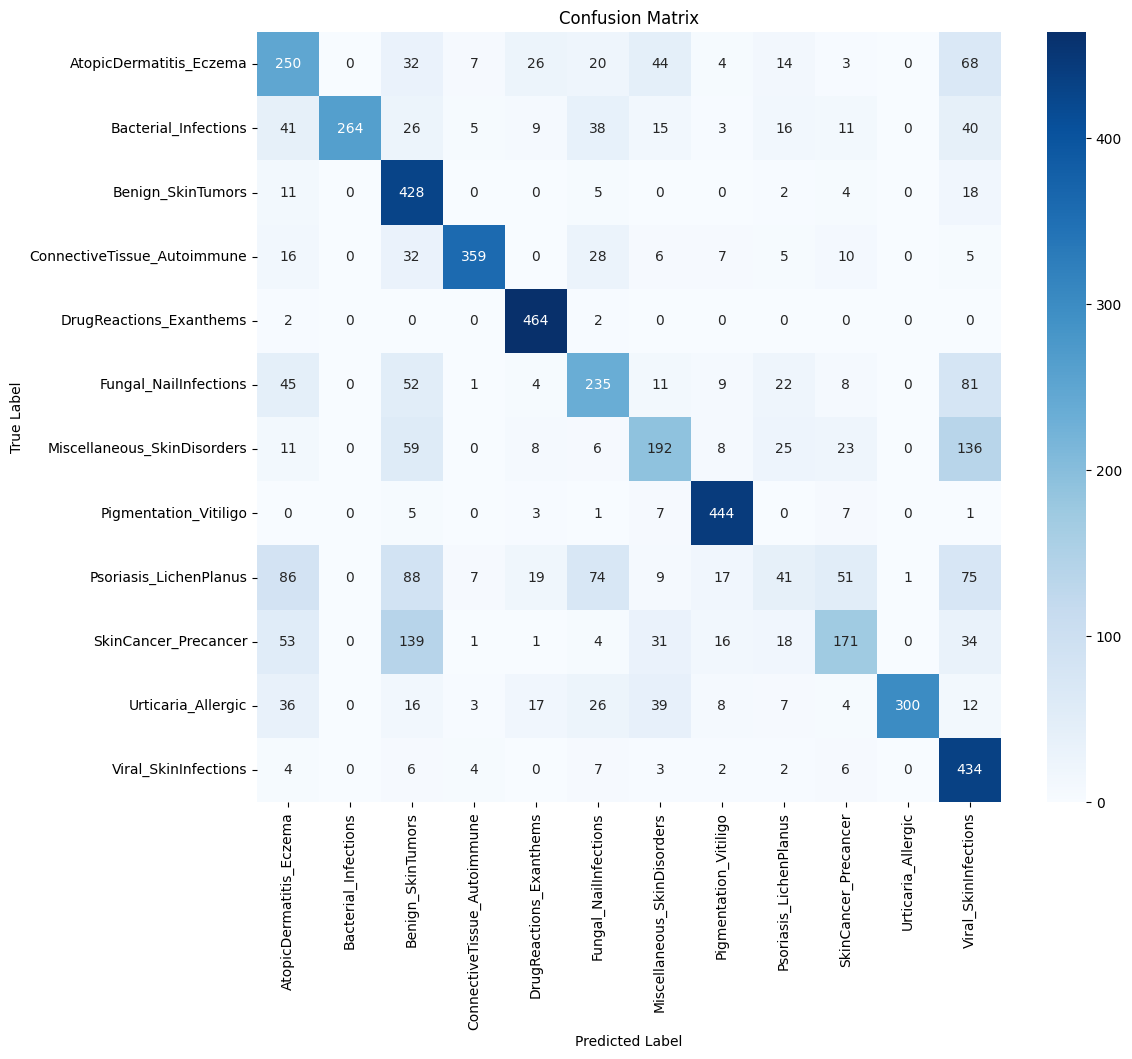

Classification Report:

                             precision    recall  f1-score   support

    AtopicDermatitis_Eczema       0.45      0.53      0.49       468
       Bacterial_Infections       1.00      0.56      0.72       468
          Benign_SkinTumors       0.48      0.91      0.63       468
ConnectiveTissue_Autoimmune       0.93      0.77      0.84       468
    DrugReactions_Exanthems       0.84      0.99      0.91       468
      Fungal_NailInfections       0.53      0.50      0.51       468
Miscellaneous_SkinDisorders       0.54      0.41      0.47       468
      Pigmentation_Vitiligo       0.86      0.95      0.90       468
     Psoriasis_LichenPlanus       0.27      0.09      0.13       468
       SkinCancer_Precancer       0.57      0.37      0.45       468
         Urticaria_Allergic       1.00      0.64      0.78       468
       Viral_SkinInfections       0.48      0.93      0.63       468

                   accuracy                           0.64      5616
        

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -----------------------------
# CONFIG
# -----------------------------
MODEL_PATH = "hybrid_final_model.keras"
DATA_ROOT = r"C:\Users\BME\Desktop\skin_dataset_13labels\train_balanced"
IMG_SIZE = (380, 380)
BATCH_SIZE = 16

# -----------------------------
# LOAD MODEL
# -----------------------------
model = tf.keras.models.load_model(MODEL_PATH)

# -----------------------------
# DATA GENERATOR (Validation/Test)
# -----------------------------
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_gen = datagen.flow_from_directory(
    DATA_ROOT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset="validation",
    class_mode="categorical",
    shuffle=False  # important for correct labels
)

# -----------------------------
# PREDICTIONS
# -----------------------------
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# -----------------------------
# CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# -----------------------------
# CLASSIFICATION REPORT
# -----------------------------
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import os

# -----------------------------
# CONFIG
# -----------------------------
MODEL_PATH = "hybrid_final_model.keras"
IMG_PATH = r"C:\Users\BME\Desktop\skin_dataset_13labels\train_balanced\AtopicDermatitis_Eczema\03DermatitisLids.jpg" # change to your test image path
IMG_SIZE = (380, 380)  # same as training

# -----------------------------
# LOAD MODEL
# -----------------------------
model = tf.keras.models.load_model(MODEL_PATH)

# -----------------------------
# LOAD CLASS INDICES
# -----------------------------
# This assumes you have the train generator saved earlier
# If not, recreate it with the same preprocessing and directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATA_ROOT = r"C:\Users\BME\Desktop\skin_dataset_13labels\train_balanced"
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_gen = datagen.flow_from_directory(
    DATA_ROOT,
    target_size=IMG_SIZE,
    batch_size=1,
    subset="training",
    class_mode="categorical",
    shuffle=False
)

class_indices = train_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

# -----------------------------
# PREPROCESS INPUT IMAGE
# -----------------------------
img = image.load_img(IMG_PATH, target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)  # shape: (1, 380, 380, 3)

# -----------------------------
# PREDICT
# -----------------------------
pred = model.predict(img_array)
pred_class = np.argmax(pred, axis=1)[0]
confidence = np.max(pred)

print(f"✅ Predicted Class: {idx_to_class[pred_class]} (confidence: {confidence:.2f})")


Found 22464 images belonging to 12 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
✅ Predicted Class: Viral_SkinInfections (confidence: 0.15)


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201, EfficientNetB4
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# CONFIG
# -----------------------------
DATA_ROOT = r"C:\Users\BME\Desktop\skin_dataset_13labels\train_balanced"
IMG_SIZE = (380, 380)
BATCH_SIZE = 32
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 40
INITIAL_LR = 1e-4
USE_EARLY_STOPPING = True   # 👈 set False to always run all epochs

# Verify directory exists
if not os.path.exists(DATA_ROOT):
    raise FileNotFoundError(f"Directory {DATA_ROOT} does not exist.")

# -----------------------------
# DATA PREP
# -----------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_ROOT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='training',
    class_mode='categorical',
    color_mode="rgb"
)

val_generator = val_datagen.flow_from_directory(
    DATA_ROOT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='validation',
    class_mode='categorical',
    color_mode="rgb",
    shuffle=False   # 👈 important for confusion matrix
)

# Dynamically set number of classes
NUM_CLASSES = len(train_generator.class_indices)
print(f"Detected {NUM_CLASSES} classes: {train_generator.class_indices}")

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

# -----------------------------
# MODEL BUILDING
# -----------------------------
input_tensor = Input(shape=(380, 380, 3))

base1 = DenseNet201(include_top=False, weights="imagenet", input_tensor=input_tensor)
x1 = GlobalAveragePooling2D()(base1.output)

base2 = EfficientNetB4(include_top=False, weights=None, input_tensor=input_tensor)
weights_path = tf.keras.utils.get_file(
    'efficientnetb4_notop.h5',
    'https://storage.googleapis.com/keras-applications/efficientnetb4_notop.h5',
    cache_subdir='models'
)
base2.load_weights(weights_path, by_name=True, skip_mismatch=True)
x2 = GlobalAveragePooling2D()(base2.output)

# Freeze base models
base1.trainable = False
base2.trainable = False

x = Concatenate()([x1, x2])
x = Dropout(0.5)(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=input_tensor, outputs=output)

# -----------------------------
# COMPILE
# -----------------------------
steps_per_epoch = train_generator.samples // BATCH_SIZE
decay_steps = steps_per_epoch * EPOCHS_PHASE2
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=decay_steps,
    alpha=1e-5
)
optimizer = Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

# -----------------------------
# CALLBACKS
# -----------------------------
checkpoint = ModelCheckpoint(
    "hybrid_best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

csv_logger = CSVLogger('training_log.csv', append=True)

callbacks = [checkpoint, csv_logger]
if USE_EARLY_STOPPING:
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,   # 👈 bigger patience
        restore_best_weights=True,
        verbose=1
    )
    callbacks.append(early_stop)

# -----------------------------
# TRAINING - PHASE 1
# -----------------------------
print("🔵 Phase 1: Training head (frozen base models)...")
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# -----------------------------
# TRAINING - PHASE 2 (Fine-tuning)
# -----------------------------
print("🟢 Phase 2: Fine-tuning base models...")
for layer in base1.layers[-100:]:
    layer.trainable = True
for layer in base2.layers[-50:]:
    layer.trainable = True

# Re-compile with lower LR
lr_schedule_finetune = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=INITIAL_LR / 10,
    decay_steps=decay_steps,
    alpha=1e-5
)
optimizer = Adam(learning_rate=lr_schedule_finetune)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# -----------------------------
# SAVE FINAL MODEL
# -----------------------------
try:
    model.save("hybrid_final_model(1).keras")
    print("✅ Training complete. Model saved.")
except Exception as e:
    print(f"❌ Error saving model: {e}")

# -----------------------------
# CONFUSION MATRIX + REPORT
# -----------------------------
print("\n📊 Generating confusion matrix on validation set...")
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


Found 22464 images belonging to 12 classes.
Found 5616 images belonging to 12 classes.
Detected 12 classes: {'AtopicDermatitis_Eczema': 0, 'Bacterial_Infections': 1, 'Benign_SkinTumors': 2, 'ConnectiveTissue_Autoimmune': 3, 'DrugReactions_Exanthems': 4, 'Fungal_NailInfections': 5, 'Miscellaneous_SkinDisorders': 6, 'Pigmentation_Vitiligo': 7, 'Psoriasis_LichenPlanus': 8, 'SkinCancer_Precancer': 9, 'Urticaria_Allergic': 10, 'Viral_SkinInfections': 11}
🔵 Phase 1: Training head (frozen base models)...


c:\Users\BME\anaconda3\envs\skin_classification_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 44/702 ━━━━━━━━━━━━━━━━━━━━ 4:43:28 26s/step - accuracy: 0.1527 - auc_3: 0.5697 - loss: 2.5956 - precision_4: 0.3655 - recall_4: 0.0045

In [2]:
# swin_training_skin.py
import sys, os
sys.path.append(os.path.dirname(os.path.abspath(__file__)))
import os
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory
from models.build import build_swin_transformer
 # from Swin-Transformer-Tensorflow repo

# --------- CONFIG ---------
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
DATA_DIR = r'C:\Users\BME\Desktop\skin_dataset_13labels\train_balanced'    # <-- update this
VAL_DIR = r'/C:\Users\BME\Desktop\skin_dataset_13labels\test'       # <-- update this
NUM_CLASSES = len(os.listdir(DATA_DIR))

# --------- DATA PIPELINE ---------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1)
])

train_ds = image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
).map(lambda x, y: (data_augmentation(x, training=True), y))

val_ds = image_dataset_from_directory(
    VAL_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# --------- MODEL SETUP ---------
model = build_swin_transformer(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    include_top=True
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# --------- CALLBACKS ---------
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "checkpoint_best_swin_skin.h5",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        patience=5,
        factor=0.5,
        verbose=1
    )
]

# --------- TRAINING ---------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# --------- SAVE FINAL MODEL ---------
model.save("final_swin_skin.h5")

NameError: name '__file__' is not defined

In [ ]:
# swin_training_skin.py
import sys, os
# ensure current folder (repo root) is in sys.path
sys.path.append(os.path.dirname(os.path.abspath(__file__)))

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory
from models.build import build_swin_transformer  # from Swin-Transformer-Tensorflow repo

# --------- CONFIG ---------
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
DATA_DIR = r'C:\Users\BME\Desktop\skin_dataset_13labels\train_balanced'   # <-- update this
VAL_DIR = r'C:\Users\BME\Desktop\skin_dataset_13labels\test'              # <-- fixed path (removed /C: )
NUM_CLASSES = len(os.listdir(DATA_DIR))

# --------- DATA PIPELINE ---------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    # RandomBrightness is not always in keras.layers — if it errors, remove this
    layers.RandomContrast(0.1)  
])

train_ds = image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
).map(lambda x, y: (data_augmentation(x, training=True), y))

val_ds = image_dataset_from_directory(
    VAL_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# --------- MODEL SETUP ---------
model = build_swin_transformer(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    include_top=True
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# --------- CALLBACKS ---------
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "checkpoint_best_swin_skin.h5",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        patience=5,
        factor=0.5,
        verbose=1
    )
]

# --------- TRAINING ---------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# --------- SAVE FINAL MODEL ---------
model.save("final_swin_skin.h5")


In [1]:
import os
import tensorflow as tf

# -------- CONFIGS --------
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 12  # Change if your dataset classes differ
TRAIN_DIR = r"C:\Users\BME\Desktop\skin_dataset_13labels\train_balanced"  # <-- change to your train set path
VAL_DIR = r'C:\Users\BME\Desktop\skin_dataset_13labels\test'        # <-- change to your validation set path

# -------- DATASET PIPELINE --------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode='categorical',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR,
    label_mode='categorical',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Optional: Prefetch for training speed
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# -------- MODEL: RESNET-V2 SLIM STYLE (VIA KERAS) --------
base_model = tf.keras.applications.ResNet50V2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = True  # Fine-tune all layers

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# -------- CHECKPOINTS & CALLBACKS --------
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    'model_checkpoint.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)
final_save_cb = tf.keras.callbacks.ModelCheckpoint(
    'slime_trained_model.h5',
    save_best_only=False,
    save_freq='epoch',
    verbose=1
)
earlystop_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# -------- TRAINING --------
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, final_save_cb, earlystop_cb]
)

print("Best and final model weights are saved!")

# -------- EVALUATE --------
print("Final evaluation on validation set:")
val_loss, val_acc = model.evaluate(val_ds)
print(f'Validation accuracy: {val_acc:.4f}')

Found 28080 files belonging to 12 classes.
Found 3511 files belonging to 12 classes.
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Epoch 1/50


c:\Users\BME\anaconda3\envs\skinenv_py310\lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


878/878 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6735 - loss: 0.9879
Epoch 1: val_accuracy improved from -inf to 0.47109, saving model to model_checkpoint.h5



Epoch 1: saving model to slime_trained_model.h5


878/878 ━━━━━━━━━━━━━━━━━━━━ 5468s 6s/step - accuracy: 0.6736 - loss: 0.9878 - val_accuracy: 0.4711 - val_loss: 1.6042
Epoch 2/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7937 - loss: 0.6332
Epoch 2: val_accuracy did not improve from 0.47109

Epoch 2: saving model to slime_trained_model.h5


...

878/878 ━━━━━━━━━━━━━━━━━━━━ 4506s 5s/step - accuracy: 0.9820 - loss: 0.0424 - val_accuracy: 0.5816 - val_loss: 2.4677
Epoch 35/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9832 - loss: 0.0395
Epoch 35: val_accuracy did not improve from 0.60011

Epoch 35: saving model to slime_trained_model.h5


878/878 ━━━━━━━━━━━━━━━━━━━━ 4504s 5s/step - accuracy: 0.9832 - loss: 0.0395 - val_accuracy: 0.5765 - val_loss: 2.4584
Epoch 36/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9860 - loss: 0.0291
Epoch 36: val_accuracy did not improve from 0.60011

Epoch 36: saving model to slime_trained_model.h5


878/878 ━━━━━━━━━━━━━━━━━━━━ 4598s 5s/step - accuracy: 0.9860 - loss: 0.0291 - val_accuracy: 0.5739 - val_loss: 2.5161
Epoch 37/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9841 - loss: 0.0323
Epoch 37: val_accuracy did not improve from 0.60011

Epoch 37: saving model to slime_trained_model.h5


878/878 ━━━━━━━━━━━━━━━━━━━━ 4546s 5s/step - accuracy: 0.9841 - loss: 0.0323 - val_accuracy: 0.5642 - val_loss: 2.6277
Epoch 38/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9838 - loss: 0.0360
Epoch 38: val_accuracy did not improve from 0.60011

Epoch 38: saving model to slime_trained_model.h5


878/878 ━━━━━━━━━━━━━━━━━━━━ 4519s 5s/step - accuracy: 0.9838 - loss: 0.0360 - val_accuracy: 0.5776 - val_loss: 2.5723
Epoch 38: early stopping
Restoring model weights from the end of the best epoch: 28.
Best and final model weights are saved!
Final evaluation on validation set:
110/110 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.5965 - loss: 2.2404
Validation accuracy: 0.6001


✅ Model loaded successfully.
Found 13603 images belonging to 12 classes.


c:\Users\BME\anaconda3\envs\skinenv_py310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


426/426 ━━━━━━━━━━━━━━━━━━━━ 613s 1s/step

✅ Test Accuracy: 17.20%

📋 Classification Report:
                             precision    recall  f1-score   support

    AtopicDermatitis_Eczema       0.00      0.00      0.00      1724
       Bacterial_Infections       0.00      0.00      0.00       288
          Benign_SkinTumors       0.00      0.00      0.00      1853
ConnectiveTissue_Autoimmune       0.00      0.00      0.00       606
    DrugReactions_Exanthems       0.00      0.00      0.00       404
      Fungal_NailInfections       0.17      1.00      0.29      2340
Miscellaneous_SkinDisorders       0.00      0.00      0.00       840
      Pigmentation_Vitiligo       0.00      0.00      0.00       568
     Psoriasis_LichenPlanus       0.00      0.00      0.00      1405
       SkinCancer_Precancer       0.00      0.00      0.00      1612
         Urticaria_Allergic       0.00      0.00      0.00       472
       Viral_SkinInfections       0.00      0.00      0.00      1491

        

c:\Users\BME\anaconda3\envs\skinenv_py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BME\anaconda3\envs\skinenv_py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BME\anaconda3\envs\skinenv_py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

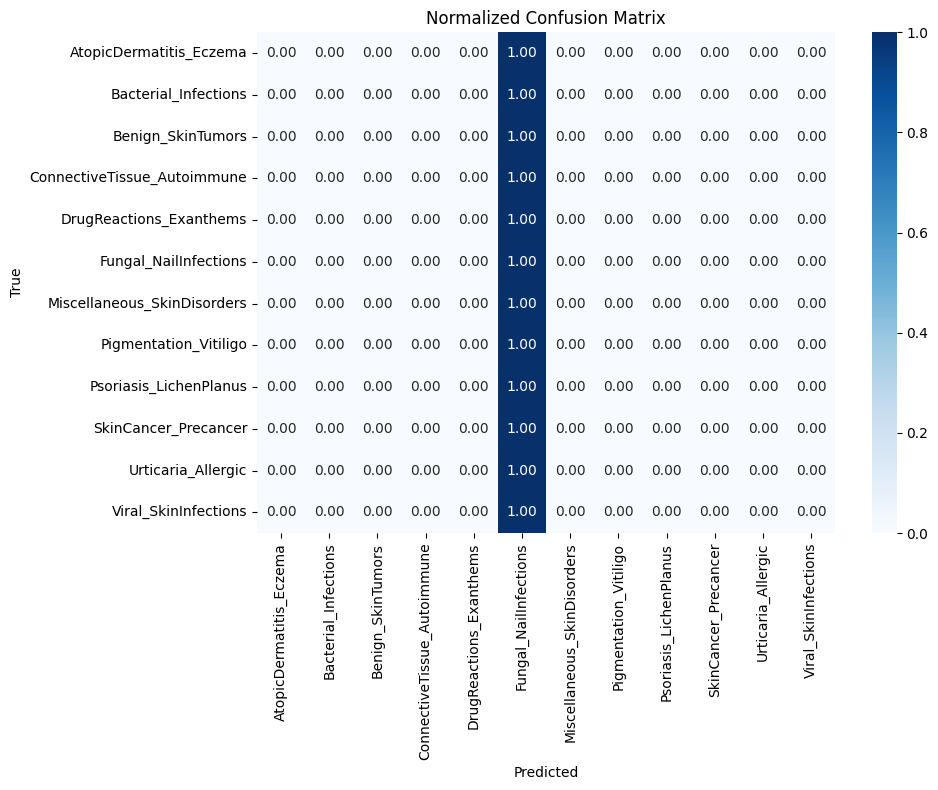

In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# === Paths ===
MODEL_PATH = r"C:\Users\BME\Desktop\slime_trained_model.h5"
TEST_DIR =  r'C:\Users\BME\Desktop\skin_dataset_13labels\train'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# === Load model ===
model = load_model(MODEL_PATH)
print("✅ Model loaded successfully.")

# === Load test data ===
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_labels = list(test_generator.class_indices.keys())
y_true = test_generator.classes

# === Predict ===
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# === Accuracy ===
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {acc * 100:.2f}%")

# === Classification Report ===
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# === Normalized Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [7]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# === Paths ===
MODEL_PATH = r"C:\Users\BME\Desktop\best_model_checkpoint.h5"
TEST_DIR = r"C:\Users\BME\Desktop\skin_dataset_13labels\test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# === Load model ===
model = load_model(MODEL_PATH)
print("✅ Model loaded successfully.")

# === Load test data ===
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_labels = list(test_generator.class_indices.keys())
y_true = test_generator.classes

# === Predict ===
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# === Accuracy ===
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {acc * 100:.2f}%")

# === Classification Report ===
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# === Normalized Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


✅ Model loaded successfully.
Found 3511 images belonging to 12 classes.


c:\Users\BME\anaconda3\envs\skinenv_py310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


110/110 ━━━━━━━━━━━━━━━━━━━━ 365s 3s/step

✅ Test Accuracy: 1.91%

📋 Classification Report:


ValueError: Number of classes, 23, does not match size of target_names, 12. Try specifying the labels parameter

In [6]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
from tensorflow.keras.applications import EfficientNetB7, DenseNet201, InceptionResNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.utils import image_dataset_from_directory
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score
import random
import matplotlib.pyplot as plt  # Optional for debugging

# Step 0: Define Dataset Path (User to replace with actual path)
DATASET_PATH = r'C:\Users\BME\Desktop\skin_dataset_13labels\train_balanced'  # Assume structure: DATASET_PATH/class1/img1.jpg, etc. for 12 classes

# Step 1: GAN for Augmentation (Simple DCGAN implementation)
class Generator(tf.keras.Model):
    def __init__(self, nz=100, ngf=64, nc=3, **kwargs):
        super(Generator, self).__init__(**kwargs)
        self.nz = nz
        self.main = tf.keras.Sequential([
            layers.Conv2DTranspose(ngf * 8, 4, strides=1, padding='valid', use_bias=False, input_shape=(1, 1, nz)),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2DTranspose(ngf * 4, 4, strides=2, padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2DTranspose(ngf * 2, 4, strides=2, padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2DTranspose(ngf, 4, strides=2, padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2DTranspose(nc, 4, strides=2, padding='same', use_bias=False),
            layers.Activation('tanh')
        ])

    def call(self, inputs, training=False):
        return self.main(tf.reshape(inputs, (-1, 1, 1, self.nz)), training=training)

class Discriminator(tf.keras.Model):
    def __init__(self, ndf=64, nc=3, **kwargs):
        super(Discriminator, self).__init__(**kwargs)
        self.main = tf.keras.Sequential([
            layers.Conv2D(ndf, 4, strides=2, padding='same', use_bias=False, input_shape=(128, 128, nc)),
            layers.LeakyReLU(0.2),
            layers.Conv2D(ndf * 2, 4, strides=2, padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(0.2),
            layers.Conv2D(ndf * 4, 4, strides=2, padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(0.2),
            layers.Conv2D(ndf * 8, 4, strides=2, padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(0.2),
            layers.Conv2D(1, 4, strides=1, padding='valid', use_bias=False),
            layers.Flatten(),
            layers.Activation('sigmoid')
        ])

    def call(self, inputs, training=False):
        return self.main(inputs, training=training)

def train_gan_for_class(class_dataset, nz=100, epochs=50, batch_size=32, lr=0.0002):
    generator = Generator(nz)
    discriminator = Discriminator()
    g_optimizer = optimizers.Adam(lr, beta_1=0.5)
    d_optimizer = optimizers.Adam(lr, beta_1=0.5)
    criterion = losses.BinaryCrossentropy()

    for epoch in range(epochs):
        for real_imgs in class_dataset:
            b_size = real_imgs.shape[0]
            real_labels = tf.ones((b_size, 1))
            fake_labels = tf.zeros((b_size, 1))

            # Train Discriminator
            with tf.GradientTape() as d_tape:
                d_real = discriminator(real_imgs, training=True)
                d_loss_real = criterion(real_labels, d_real)
                noise = tf.random.normal((b_size, nz))
                fake_imgs = generator(noise, training=True)
                d_fake = discriminator(fake_imgs, training=True)
                d_loss_fake = criterion(fake_labels, d_fake)
                d_loss = d_loss_real + d_loss_fake
            d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
            d_optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))

            # Train Generator
            with tf.GradientTape() as g_tape:
                noise = tf.random.normal((b_size, nz))
                fake_imgs = generator(noise, training=True)
                d_fake = discriminator(fake_imgs, training=True)
                g_loss = criterion(real_labels, d_fake)
            g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
            g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))

        print(f'GAN Epoch [{epoch+1}/{epochs}] Loss D: {d_loss.numpy():.4f}, Loss G: {g_loss.numpy():.4f}')

    return generator, g_loss.numpy()  # Return generator and last G loss

def augment_with_gan(class_names, min_samples_per_class=500, nz=100):
    augmented_images = []
    augmented_labels = []

    for idx, cls in enumerate(class_names):
        class_path = os.path.join(DATASET_PATH, cls)
        class_files = os.listdir(class_path)
        count = len(class_files)
        if count < min_samples_per_class:
            num_to_generate = min_samples_per_class - count
            # Load class images for GAN training (resize to 128x128 for GAN)
            class_images = []
            for file in class_files:
                img = load_img(os.path.join(class_path, file), target_size=(128, 128))
                img = img_to_array(img) / 255.0 * 2 - 1  # Normalize to [-1,1]
                class_images.append(img)
            class_dataset = tf.data.Dataset.from_tensor_slices(class_images).shuffle(1000).batch(32)

            generator, _ = train_gan_for_class(class_dataset, nz)

            for _ in range(num_to_generate):
                noise = tf.random.normal((1, nz))
                fake_img = generator(noise, training=False)[0]
                fake_img = (fake_img.numpy() + 1) / 2 * 255  # Denormalize to [0,255]
                augmented_images.append(fake_img.astype(np.uint8))
                augmented_labels.append(idx)

    # For TF dataset, we can create a dataset from augmented
    if augmented_images:
        augmented_ds = tf.data.Dataset.from_tensor_slices((augmented_images, augmented_labels))
    else:
        augmented_ds = None

    return augmented_ds

# Step 2: Hybrid Model Definition (CHASHNIt)
class CHASHNIt(tf.keras.Model):
    def __init__(self, num_classes=12, **kwargs):  # Updated to 12 classes
        super(CHASHNIt, self).__init__(**kwargs)
        self.efficientnet = EfficientNetB7(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
        self.densenet = DenseNet201(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
        self.inceptionresnet = InceptionResNetV2(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))

        self.bn_eff = layers.BatchNormalization()
        self.bn_dense = layers.BatchNormalization()
        self.bn_inc = layers.BatchNormalization()

        self.conv_reduce = layers.Conv2D(512, kernel_size=1, activation='relu')  # Reduced filters for efficiency

        self.global_pool = layers.GlobalAveragePooling2D()
        self.classifier = layers.Dense(num_classes, activation='softmax')  # Updated to 12 classes

    def call(self, inputs, training=False):
        feat_eff = self.efficientnet(inputs, training=training)
        feat_dense = self.densenet(inputs, training=training)
        feat_inc = self.inceptionresnet(inputs, training=training)

        # Normalize
        feat_eff = self.bn_eff(feat_eff, training=training)
        feat_eff = (feat_eff - tf.reduce_min(feat_eff)) / (tf.reduce_max(feat_eff) - tf.reduce_min(feat_eff) + 1e-6)

        feat_dense = self.bn_dense(feat_dense, training=training)
        feat_dense = (feat_dense - tf.reduce_min(feat_dense)) / (tf.reduce_max(feat_dense) - tf.reduce_min(feat_dense) + 1e-6)

        feat_inc = self.bn_inc(feat_inc, training=training)
        feat_inc = (feat_inc - tf.reduce_min(feat_inc)) / (tf.reduce_max(feat_inc) - tf.reduce_min(feat_inc) + 1e-6)

        fused = tf.concat([feat_eff, feat_dense, feat_inc], axis=-1)
        reduced = self.conv_reduce(fused)

        pooled = self.global_pool(reduced)
        return self.classifier(pooled)

# Step 3: Data Preparation
IMG_SIZE = 224  # Note: EfficientNetB7 prefers 600x600, DenseNet201 prefers 224x224, adjust if needed
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    zoom_range=0.2,
    validation_split=0.2  # For 80:20 split
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

test_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())

# Augment with GAN
augmented_ds = augment_with_gan(class_names)

if augmented_ds:
    # Convert generators to datasets for concatenation
    train_ds = tf.data.Dataset.from_generator(
        lambda: train_generator,
        output_types=(tf.float32, tf.float32),
        output_shapes=((None, IMG_SIZE, IMG_SIZE, 3), (None, 12))  # Updated to 12 classes
    ).repeat()  # For infinite if needed

    # Map augmented to match
    augmented_ds = augmented_ds.map(lambda img, lbl: (tf.image.resize(img / 255.0, (IMG_SIZE, IMG_SIZE)), tf.one_hot(lbl, 12)))  # Updated to 12 classes
    augmented_ds = augmented_ds.batch(BATCH_SIZE)

    train_ds = train_ds.concatenate(augmented_ds).prefetch(tf.data.AUTOTUNE)
else:
    train_ds = tf.data.Dataset.from_generator(
        lambda: train_generator,
        output_types=(tf.float32, tf.float32),
        output_shapes=((None, IMG_SIZE, IMG_SIZE, 3), (None, 12))  # Updated to 12 classes
    ).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    lambda: test_generator,
    output_types=(tf.float32, tf.float32),
    output_shapes=((None, IMG_SIZE, IMG_SIZE, 3), (None, 12))  # Updated to 12 classes
).prefetch(tf.data.AUTOTUNE)

# Step 4: Training Setup
model = CHASHNIt(num_classes=12)  # Updated to 12 classes
criterion_ce = losses.CategoricalCrossentropy()

optimizer = optimizers.Adam(learning_rate=1e-7)

# For GAN loss approximation
alpha = 0.4
avg_l_g = 0.5  # Placeholder from GAN

# Freeze all except classifier and reduction
model.efficientnet.trainable = False
model.densenet.trainable = False
model.inceptionresnet.trainable = False

# Compile for training
model.compile(optimizer=optimizer, loss=criterion_ce, metrics=['accuracy'])

num_epochs = 100
checkpoint_dir = './checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint = tf.train.Checkpoint(model=model, optimizer=optimizer)

# Custom training loop to incorporate total loss
for epoch in range(num_epochs):
    running_loss = 0.0
    steps = 0
    for inputs, labels in train_ds.take(len(train_generator)):
        with tf.GradientTape() as tape:
            outputs = model(inputs, training=True)
            loss_ce = criterion_ce(labels, outputs)
            loss_total = (1 - alpha) * loss_ce + alpha * avg_l_g
        grads = tape.gradient(loss_total, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        running_loss += loss_total.numpy()
        steps += 1

    print(f'Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss / steps:.4f}')

    # Checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        checkpoint.save(os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}'))

    # After 50 epochs, unfreeze
    if epoch == 49:
        model.efficientnet.trainable = True
        model.densenet.trainable = True
        model.inceptionresnet.trainable = True
        model.compile(optimizer=optimizer, loss=criterion_ce, metrics=['accuracy'])  # Recompile if needed

# Save final model
model.save_weights('chashnit_final.weights.h5')

# Step 5: Evaluation
all_preds = []
all_labels = []
for inputs, labels in test_ds.take(len(test_generator)):
    outputs = model(inputs, training=False)
    preds = tf.argmax(outputs, axis=1).numpy()
    true = tf.argmax(labels, axis=1).numpy()
    all_preds.extend(preds)
    all_labels.extend(true)

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')

print(f'Test Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')

# Note: This TensorFlow implementation aims to replicate the PyTorch version closely. To run in VS Code, ensure TensorFlow is installed (pip install tensorflow). The code assumes GPU availability but runs on CPU if not. Exact accuracy may vary slightly due to framework differences.

Found 22464 images belonging to 12 classes.
Found 5616 images belonging to 12 classes.


InvalidArgumentError: Exception encountered when calling CHASHNIt.call().

[1m{{function_node __wrapped__ConcatV2_N_3_device_/job:localhost/replica:0/task:0/device:CPU:0}} ConcatOp : Dimension 1 in both shapes must be equal: shape[0] = [32,7,7,2560] vs. shape[2] = [32,5,5,1536] [Op:ConcatV2] name: concat[0m

Arguments received by CHASHNIt.call():
  • inputs=tf.Tensor(shape=(32, 224, 224, 3), dtype=float32)
  • training=True

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -----------------------------
# CONFIG
# -----------------------------
MODEL_PATH = r"C:\Users\BME\Desktop\hybrid_final_model.keras"
DATA_ROOT = r"C:\Users\BME\Desktop\skin_dataset_13labels\train_balanced"
IMG_SIZE = (380, 380)
BATCH_SIZE = 16

# -----------------------------
# LOAD MODEL
# -----------------------------
model = tf.keras.models.load_model(MODEL_PATH)

# -----------------------------
# DATA GENERATOR (Validation/Test)
# -----------------------------
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_gen = datagen.flow_from_directory(
    DATA_ROOT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset="validation",
    class_mode="categorical",
    shuffle=False  # important for correct labels
)

# -----------------------------
# PREDICTIONS
# -----------------------------
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# -----------------------------
# CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# -----------------------------
# CLASSIFICATION REPORT
# -----------------------------
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


Found 5616 images belonging to 12 classes.


c:\Users\BME\anaconda3\envs\skinenv_py310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 52/351 ━━━━━━━━━━━━━━━━━━━━ 26:54 5s/step

In [ ]:
import pickle
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# --------- Step 1: Load the trained model ---------
model_path = "C:/Users/BME/Desktop/resnet152v2_effnetb4_best_model.keras"

# If you have custom layers, define them here:
# from your_custom_module import CustomLayer
# custom_objects = {'CustomLayer': CustomLayer}
# model = load_model(model_path, custom_objects=custom_objects)

# If no custom layers:
model = load_model(model_path)
print("Model loaded successfully!")

# --------- Step 2: Load the training history ---------
history_path = "C:/Users/BME/Desktop/training_history.pkl"

with open(history_path, "rb") as f:
    history = pickle.load(f)  # history is now a dictionary

print("Training history loaded successfully!")
print("Keys available in history:", history.keys())

# --------- Step 3: Plot Accuracy ---------
plt.figure(figsize=(8,6))
plt.plot(history['accuracy'], marker='o')
plt.plot(history['val_accuracy'], marker='x')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

# --------- Step 4: Plot Loss ---------
plt.figure(figsize=(8,6))
plt.plot(history['loss'], marker='o')
plt.plot(history['val_loss'], marker='x')
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()